# Employee Performance Analysis - Complete Exam Solution

## Part A - Theory Answers

### 1. Mean, Median and Mode
Mean is the average salary of employees. Median is the middle salary when arranged in order. Mode is the salary value that occurs most frequently.

### 2. Range and Variance
Range = Maximum Value - Minimum Value. Variance measures how far values are spread from the mean.

### 3. Normal Distribution vs Poisson Distribution
Normal Distribution is continuous and bell-shaped. Poisson Distribution is discrete and used for counting events occurring in a fixed interval.

### 4. Skewness
Skewness measures the asymmetry of a distribution. Positive skew means a longer right tail and negative skew means a longer left tail.

### 5. Conditional Probability
Conditional probability is the probability of an event occurring given that another event has already occurred. Example: P(Promotion | Performance Score > 80).

### 6. Independent vs Mutually Exclusive Events
Independent events do not affect each other. Mutually exclusive events cannot occur at the same time.

### 7. Bayes Theorem
Bayes Theorem updates probabilities using new evidence and helps in decision-making and prediction.

### 8. PCA (Principal Component Analysis)
PCA reduces the number of variables while retaining maximum information from the dataset.

## Part B : Practical 



In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import math

In [4]:
df = pd.read_csv("Data\employee_performance.csv")
df

<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\nevil\AppData\Local\Temp\ipykernel_3056\3833272456.py:1: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  df = pd.read_csv("Data\employee_performance.csv")


,Employee_ID,Department,Age,Salary,Projects_Completed,Working_Hours,Performance_Score,Promotion_Status
0,1,Sales,42,50008,8,34,74,No
1,2,Marketing,41,73928,8,53,79,No
2,3,Finance,40,108096,7,33,63,No
3,4,Marketing,40,114876,6,50,85,No
4,5,Marketing,33,49976,6,44,67,No
...,...,...,...,...,...,...,...,...
3995,3996,HR,56,72042,13,34,96,Yes
3996,3997,Sales,47,74116,8,41,92,Yes
3997,3998,HR,39,51325,12,43,100,Yes
3998,3999,Operations,50,47597,9,35,73,No


#### Step 1 : Central Tendency & Disperson 
##### - Find mean, median and mode of Salary.
##### - Calculate variance and standard deviation of Projects_Completed.

In [6]:
#   Mean, Median and Mode of Salary


emp_salary = df["Salary"]

print("Mean of Salary: ",np.mean(emp_salary))
print("Median of Salary: ",np.median(emp_salary))
print("mode of Salary: ",emp_salary.mode()[0])

Mean of Salary:  72635.07725
Median of Salary:  72652.5
mode of Salary:  25255


In [7]:
# Variance & Standard Deviation of 'Projects_Completed'

pro_completed = df["Projects_Completed"]

print("Variance of Projects_Completed: ",np.var(pro_completed))
print("Standard Deviation of Projects_Completed: ", np.std(pro_completed))

Variance of Projects_Completed:  16.18640975
Standard Deviation of Projects_Completed:  4.023233742898864


#### Step 2 : Probability & Events
##### - Find the probability of employees getting promoted.
##### - Create a contingency table between Promotion_Status and Department.
##### - Compute conditional probability: (Promotion | Performance_Score > 80)

In [8]:
# Find the probability of employees getting promoted

promoted_emp = df[df["Promotion_Status"] == "Yes"].shape[0]
total_emp = df["Employee_ID"].nunique()
print("Total Promoted Students: ",promoted_emp)
print("Total Employees: ",total_emp)

prob = promoted_emp/total_emp
print("Probability of Employees getting promoted: ",prob)

Total Promoted Students:  1889
Total Employees:  4000
Probability of Employees getting promoted:  0.47225


In [9]:
# Create a contingency table between Promotion_Status and Department

contingency_table = pd.crosstab(df["Promotion_Status"], df["Department"])
contingency_table

Department,Finance,HR,IT,Marketing,Operations,Sales
Promotion_Status,,,,,,
No,347,359,346,334,349,376
Yes,294,324,299,351,312,309


In [11]:
# Compute conditional probability: (Promotion | Performance_Score > 80)

promotion_yes = df[df["Promotion_Status"] == "Yes"]

score_above_80 = df[df["Performance_Score"] > 80]

yes_above_80 = df[
    (df["Promotion_Status"] == "Yes") & 
    (df["Performance_Score"] > 80)
    ]


p_promotion_given_above_80 = len(yes_above_80)/len(score_above_80)
print("Conditional Probability (Promotion | performance > 80): ",p_promotion_given_above_80)


Conditional Probability (Promotion | performance > 80):  0.8881053126469205


#### Step 3 : Distributions & Visualization
##### - Plot a Histogram of Performance_Score with a Gaussian curve.
##### - Check Skewness and Kurtosis for Salary.
##### - Draw a Q-Q Plot of Projects_Completed.

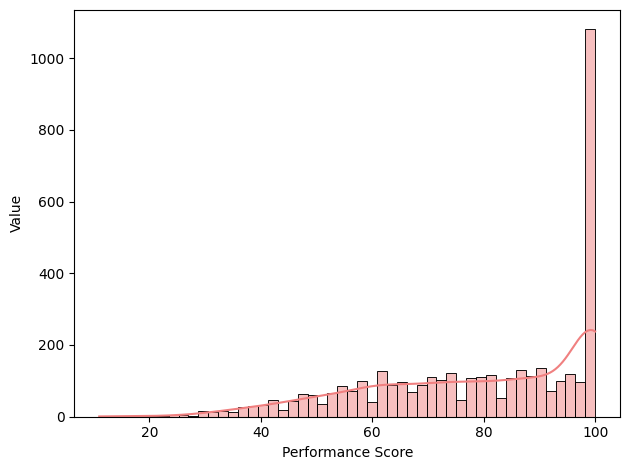

In [12]:
# Plot a Histogram of Performance_Score with a Gaussian curve

performace_score = df["Performance_Score"]

plt.figure()
sns.histplot(performace_score, bins=50, color="lightcoral", kde = True)
plt.xlabel("Performance Score")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [13]:
# Check Skewness and Kurtosis for Salary

# ----- Manual Skewness -----
n = len(emp_salary)
mean = np.mean(emp_salary)
median = np.median(emp_salary)
mode = emp_salary.mode()[0]
std = np.std(emp_salary)

third_moment = np.mean((emp_salary - mean)**3)
manual_skew = (third_moment/(std**3)) * (n**2 / ((n - 1) * (n - 2)))

print("Manual Skewness of Salary: ",manual_skew)


# ----- Scipy Skewness -----
scipy_skew = emp_salary.skew()
print("Scipy Skewness of Salary: ", scipy_skew)



# ----- Manual Kurtosis -----
fourth_moment = np.mean((emp_salary - mean)**4)
kurt_uncorrected = fourth_moment / (std**4)

bias_correction = ((n - 1) / ((n - 2) * (n - 3))) * ((n + 1) * (kurt_uncorrected * ((n-1)/n)) - 3 * (n - 1)) + 3
manual_kurt = bias_correction - 3  # Subtract 3 to make it "Excess" Kurtosis

print("Manual Kurtosis of Salary: ",manual_kurt)


# ----- Scipy Kurtosis -----
scipy_kurt = emp_salary.kurtosis()
print("Scipy Kurtosis of Salary: ",scipy_kurt)

Manual Skewness of Salary:  -0.008771167116416978
Scipy Skewness of Salary:  -0.008767878134331107
Manual Kurtosis of Salary:  -1.2298777802811265
Scipy Kurtosis of Salary:  -1.2294345759559897


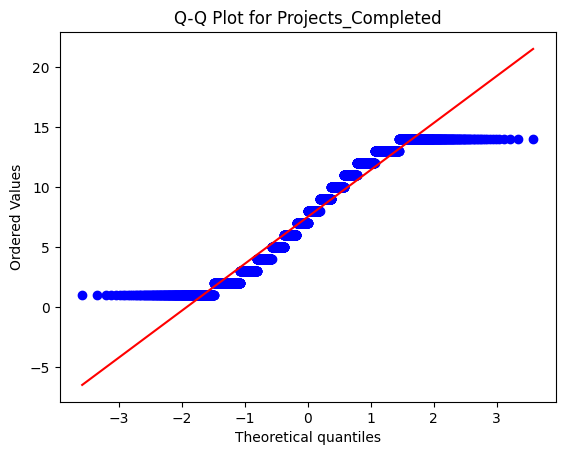

In [14]:
#  Draw a Q-Q Plot of Projects_Completed

stats.probplot(pro_completed, dist="norm", plot=plt)
plt.title("Q-Q Plot for Projects_Completed")
plt.show()

#### Step 4 : Linear Algebra Application
##### Take the first 5 employees' [Projects_Completed, Working_Hours] as vector
##### - Perform dot product between two employee vectors.
##### - Find Norm 1 & Norm 2 of an employee's work vector.
##### - Compute the angle between two employees' work vector.

In [17]:
# First 5 employees [Projects_Completed, Working_Hours] as vector
v1 = df.iloc[0][["Projects_Completed","Working_Hours"]].values
v2 = df.iloc[1][["Projects_Completed","Working_Hours"]].values
v3 = df.iloc[2][["Projects_Completed","Working_Hours"]].values
v4 = df.iloc[3][["Projects_Completed","Working_Hours"]].values
v5 = df.iloc[4][["Projects_Completed","Working_Hours"]].values

# -------------------------------------------------
# Perform dot product between two employee vectors
# -------------------------------------------------

# Manual Dot Product
dot_manual = v1[0]*v2[0] + v1[1]*v2[1]

# NumPy Dot Product
dot_numpy = np.dot(v1, v2)


# Output
print("Vector a:", v1)
print("Vector b:", v2)

print("\nManual Dot Product:", dot_manual)
print("NumPy Dot Product:", dot_numpy)


Vector a: [np.int64(8) np.int64(34)]
Vector b: [np.int64(8) np.int64(53)]

Manual Dot Product: 1866
NumPy Dot Product: 1866


In [ ]:
# Find Norm 1 & Norm 2 of an employee's work vector


# ----------- Manual Calculation -----------
v3_L1_manual = np.sum(np.abs(v3)) 
v3_L2_manual = np.sqrt(np.sum(v3**2))

v4_L1_manual = np.sum(np.abs(v4)) 
v4_L2_manual = np.sqrt(np.sum(v4**2))
# ----------- Numpy Calculation -----------
v3_L1_numpy = np.linalg.norm(v3, ord=1)
v3_L2_numpy = np.linalg.norm(v3, ord=2)

v4_L1_numpy = np.linalg.norm(v4, ord=1)
v4_L2_numpy = np.linalg.norm(v4, ord=2)

print("Vector:", v3)
print("Vector:", v4)

print("\n----------------------------")
print("L1 & L2 Norms of Vector 3:")
print("----------------------------")

print("\nL1 Norm (Manual):", v3_L1_manual)
print("L1 Norm (NumPy):", v3_L1_numpy)

print("\nL2 Norm (Manual):", v3_L2_manual)
print("L2 Norm (NumPy):", v3_L2_numpy)

print("\n----------------------------")
print("L1 & L2 Norms of Vector 4:")
print("----------------------------")

print("\nL1 Norm (Manual):", v4_L1_manual)
print("L1 Norm (NumPy):", v4_L1_numpy)

print("\nL2 Norm (Manual):", v4_L2_manual)
print("L2 Norm (NumPy):", v4_L2_numpy)

Vector: [np.int64(7) np.int64(33)]
Vector: [np.int64(6) np.int64(50)]

----------------------------
L1 & L2 Norms of Vector 3:
----------------------------

L1 Norm (Manual): 40
L1 Norm (NumPy): 40

L2 Norm (Manual): 33.734255586866
L2 Norm (NumPy): 33.734255586866

----------------------------
L1 & L2 Norms of Vector 4:
----------------------------

L1 Norm (Manual): 56
L1 Norm (NumPy): 56

L2 Norm (Manual): 50.35871324805669
L2 Norm (NumPy): 50.35871324805669


Angle between two vector (v4 & v5):  0.9223926057946168


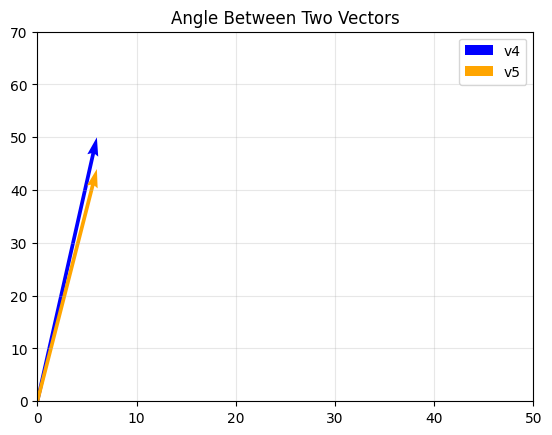

In [19]:

# Compute the angle between two employees' work vector

dot_product = np.dot(v4, v5)
mag_A = np.linalg.norm(v4)
mag_B = np.linalg.norm(v5)

cos_theta = dot_product / (mag_A * mag_B)
angle = np.degrees(np.arccos(cos_theta))

print("Angle between two vector (v4 & v5): ", angle)


plt.quiver(0, 0, v4[0], v4[1], angles="xy", scale_units="xy", scale=1, label="v4", color="blue")
plt.quiver(0, 0, v5[0], v5[1], angles="xy", scale_units="xy", scale=1, label="v5", color="orange")
plt.xlim(0, 50)
plt.ylim(0, 70)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Angle Between Two Vectors")
plt.show()